# ResNet50 Transfer Learning for Deepfake Audio Detection

This notebook trains a ResNet50-based model for classifying audio spectrograms as real or fake.

## Model Architecture:
- **Base**: ResNet50 pretrained on ImageNet (frozen layers)
- **Head**: Flatten → Dense(512) → Dropout(0.3) → Dense(512) → Dropout(0.3) → Dense(1, sigmoid)
- **Output**: Binary classification (real vs fake)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# TensorFlow configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.18.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [2]:
# Paths
BASE_DIR = Path('../')
SPECTROGRAM_DIR = BASE_DIR / 'data' / 'spectrograms'
MODEL_DIR = BASE_DIR / 'models' / 'audio' / 'resnet50'

# Training parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 2e-5

# Class names
CLASS_NAMES = ['fake', 'real']

print(f"Spectrogram directory: {SPECTROGRAM_DIR}")
print(f"Model output directory: {MODEL_DIR}")

Spectrogram directory: ../data/spectrograms
Model output directory: ../models/audio/resnet50


## Load Dataset

In [3]:
# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'training'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'validation'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPECTROGRAM_DIR / 'testing'),
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=42
)

print(f"\nClass names: {train_ds.class_names}")

Found 13956 files belonging to 2 classes.


2026-01-10 17:34:42.588928: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-01-10 17:34:42.588960: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-01-10 17:34:42.588963: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1768062882.589213 1000724 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768062882.589427 1000724 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 2826 files belonging to 2 classes.
Found 1088 files belonging to 2 classes.

Class names: ['fake', 'real']


In [4]:
# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Build ResNet50 Model

In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Rescaling
from tensorflow.keras.optimizers import RMSprop

# Load ResNet50 base model (pretrained on ImageNet)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Base model layers: 175
Trainable layers: 0


In [6]:
# Build model with custom classification head
model = Sequential([
    # Input normalization
    Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
    # Pretrained ResNet50 base
    base_model,
    
    # Classification head
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='resnet50_deepfake_detector')

model.summary()

/Users/corentin/Documents/ESILV/A5/ExplainabilityAI/projet-xai-unifie/xai_venv/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "resnet50_deepfake_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,231,617 (286.99 MB)

 Trainable params: 51,643,905 (197.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [7]:
# Compile model
model.compile(
    optimizer=RMSprop(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


## Train Model

In [8]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7
    )
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-01-10 17:34:51.033672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


437/437 ━━━━━━━━━━━━━━━━━━━━ 106s 234ms/step - accuracy: 0.5819 - loss: 0.9189 - val_accuracy: 0.5336 - val_loss: 0.9426 - learning_rate: 2.0000e-05
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 123s 281ms/step - accuracy: 0.6354 - loss: 0.9578 - val_accuracy: 0.5814 - val_loss: 0.8569 - learning_rate: 2.0000e-05
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 123s 281ms/step - accuracy: 0.6618 - loss: 0.9048 - val_accuracy: 0.5729 - val_loss: 0.9370 - learning_rate: 2.0000e-05
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 124s 282ms/step - accuracy: 0.6992 - loss: 0.7669 - val_accuracy: 0.5987 - val_loss: 0.8401 - learning_rate: 2.0000e-05
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 123s 282ms/step - accuracy: 0.7329 - loss: 0.6473 - val_accuracy: 0.7176 - val_loss: 0.5756 - learning_rate: 2.0000e-05
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 127s 289ms/step - accuracy: 0.7511 - loss: 0.5793 - val_accuracy: 0.8294 - val_loss: 0.3942 - learning_rate: 2.0000e-05
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 122s 278ms/

## Training Results

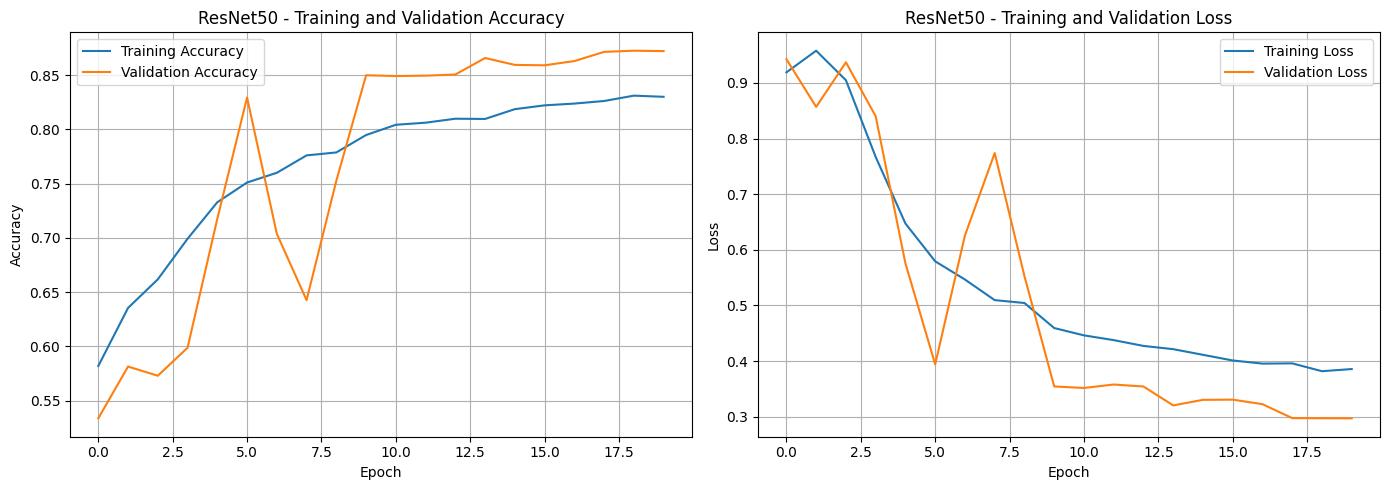

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('ResNet50 - Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('ResNet50 - Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluate on Test Set

In [10]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.5239 - loss: 1.0718

Test Loss: 1.0718
Test Accuracy: 0.5239


Classification Report:
              precision    recall  f1-score   support

        fake       0.51      0.83      0.63       544
        real       0.56      0.22      0.32       544

    accuracy                           0.52      1088
   macro avg       0.54      0.52      0.48      1088
weighted avg       0.54      0.52      0.48      1088



2026-01-10 18:15:45.939107: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


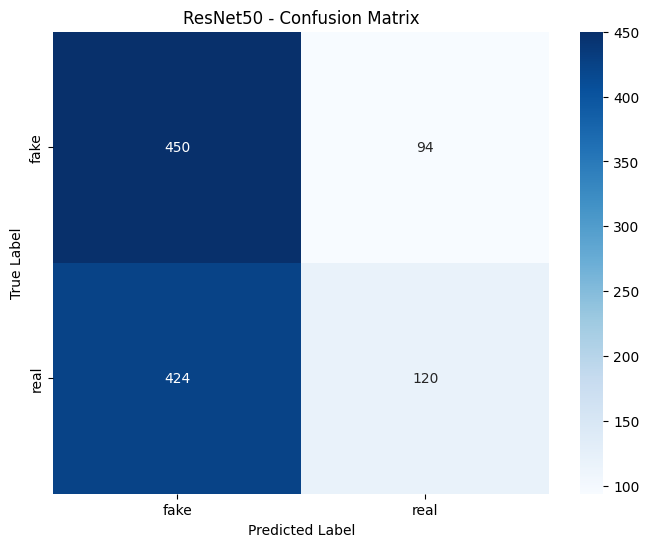

In [11]:
# Generate predictions for confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Save Model

In [12]:
# Create model directory if it doesn't exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save as .keras format
MODEL_PATH = MODEL_DIR / 'resnet50_model.keras'
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# Load the model
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")
print("Input shape:", loaded_model.input_shape)
print("Output shape:", loaded_model.output_shape)

Model saved to: ../models/audio/resnet50/resnet50_model.keras
Model loaded successfully!
Input shape: (None, 224, 224, 3)
Output shape: (None, 1)


## Summary

The ResNet50 model has been trained and saved to `models/audio/resnet50/`.

### Model Details:
- **Base**: ResNet50 pretrained on ImageNet (frozen)
- **Custom head**: Flatten → Dense(512) → Dropout(0.3) → Dense(512) → Dropout(0.3) → Dense(1)
- **Input**: 224x224x3 RGB spectrograms
- **Output**: Binary probability (fake/real)

The model can be loaded for inference using:
```python
model = tf.keras.models.load_model('models/audio/resnet50')
```